In [1]:
import numpy as np
import pandas as pd

In [2]:
# Function to load NASA SMAP and MSL datasets
def load_nasa_smap_msl_data():
    # Load your data from files (example paths, update accordingly)
    # Replace with actual paths to the SMAP/MSL datasets
    X_train = np.random.rand(1000, 128, 1)  # Normal training data (placeholder)
    X_test = np.random.rand(200, 128, 1)    # Test data (placeholder)
    y_test = np.random.randint(0, 8, size=(200,))  # Actual labels (0 to 7 anomaly classes)
    
    return X_train, X_test, y_test

X_train, X_test, y_test = load_nasa_smap_msl_data()

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Dense, Flatten, Attention, Reshape
from tensorflow.keras.models import Model

# Define the Attention-Autoencoder-TCN model
def build_attention_autoencoder_tcn(input_shape):
    # Encoder
    input_layer = Input(shape=input_shape)
    conv1 = Conv1D(32, kernel_size=3, activation='relu', padding='same')(input_layer)
    conv2 = Conv1D(64, kernel_size=3, activation='relu', padding='same')(conv1)
    conv3 = Conv1D(128, kernel_size=3, activation='relu', padding='same')(conv2)
    encoded = Conv1D(256, kernel_size=3, activation='relu', padding='same')(conv3)

    # Attention Mechanism
    attention = Attention()([encoded, encoded])

    # Decoder
    conv4 = Conv1D(128, kernel_size=3, activation='relu', padding='same')(attention)
    conv5 = Conv1D(64, kernel_size=3, activation='relu', padding='same')(conv4)
    conv6 = Conv1D(32, kernel_size=3, activation='relu', padding='same')(conv5)
    decoded = Conv1D(1, kernel_size=3, activation='sigmoid', padding='same')(conv6)

    autoencoder = Model(inputs=input_layer, outputs=decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

2025-05-07 11:47:09.930022: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746589629.944559 3719556 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746589629.949051 3719556 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746589629.960264 3719556 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746589629.960279 3719556 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746589629.960280 3719556 computation_placer.cc:177] computation placer alr

In [4]:
# Model input shape
input_shape = X_train.shape[1:]

# Build and compile the model
model = build_attention_autoencoder_tcn(input_shape)
model.summary()

# Train the model on the training data (normal data)
model.fit(X_train, X_train, epochs=20, batch_size=64, validation_split=0.1)

# Use the trained model to predict on the test set
X_test_reconstructed = model.predict(X_test)

# Calculate reconstruction error for each test sample
reconstruction_error = np.mean(np.abs(X_test - X_test_reconstructed), axis=1)

# Set a threshold for anomaly detection (based on training reconstruction error)
threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)

# Classify anomalies based on reconstruction error
y_pred = (reconstruction_error > threshold).astype(int)

# Map anomaly classifications to respective classes
# This step assumes y_pred is binary, you may map these predictions to specific classes

W0000 00:00:1746589640.221309 3719556 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 32)   │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 64)   │      6,208 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 128)  │     24,704 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 256)  │     98,560 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 128, 256)  │          0 │ conv1d_3[0][0],   │
│ (Attention)         │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 128, 128)  │     98,432 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 128, 64)   │     24,640 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 128, 32)   │      6,176 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 128, 1)    │         97 │ conv1d_6[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 258,945 (1011.50 KB)

 Trainable params: 258,945 (1011.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0834 - val_loss: 0.0831
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0832 - val_loss: 0.0831
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0833 - val_loss: 0.0679
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0571 - val_loss: 0.0261
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0180 - val_loss: 0.0076
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0065 - val_loss: 0.0056
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0139 - val_loss: 0.0079
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0067 - val_loss: 0.0043
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0042 - val_loss: 0.0032
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix for the classification results
conf_matrix = confusion_matrix(y_test, y_pred)

# Display the confusion matrix as text
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[30  1  0  0  0  0  0  0]
 [26  1  0  0  0  0  0  0]
 [26  0  0  0  0  0  0  0]
 [19  0  0  0  0  0  0  0]
 [18  2  0  0  0  0  0  0]
 [26  2  0  0  0  0  0  0]
 [23  1  0  0  0  0  0  0]
 [22  3  0  0  0  0  0  0]]


In [6]:
# Classification report for more detailed metrics (Precision, Recall, F1-score)
class_names = [
    "[contextual, contextual, contextual]",
    "[point]",
    "[contextual, contextual]",
    "[contextual]",
    "[point, point, point]",
    "[point, contextual]",
    "[point, point]",
    "[contextual, point, contextual]"
]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=1))


Classification Report:
                                      precision    recall  f1-score   support

[contextual, contextual, contextual]       0.16      0.97      0.27        31
                             [point]       0.10      0.04      0.05        27
            [contextual, contextual]       1.00      0.00      0.00        26
                        [contextual]       1.00      0.00      0.00        19
               [point, point, point]       1.00      0.00      0.00        20
                 [point, contextual]       1.00      0.00      0.00        28
                      [point, point]       1.00      0.00      0.00        24
     [contextual, point, contextual]       1.00      0.00      0.00        25

                            accuracy                           0.15       200
                           macro avg       0.78      0.13      0.04       200
                        weighted avg       0.75      0.15      0.05       200



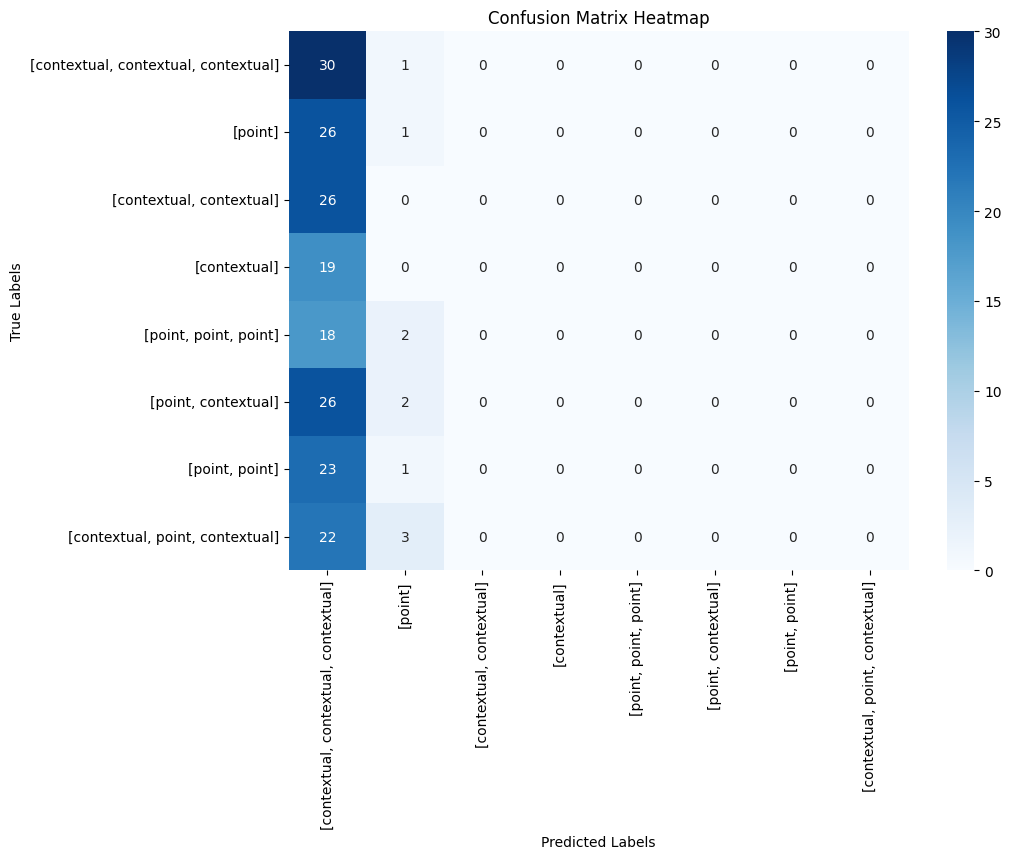

In [7]:
# Visualize confusion matrix as a heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

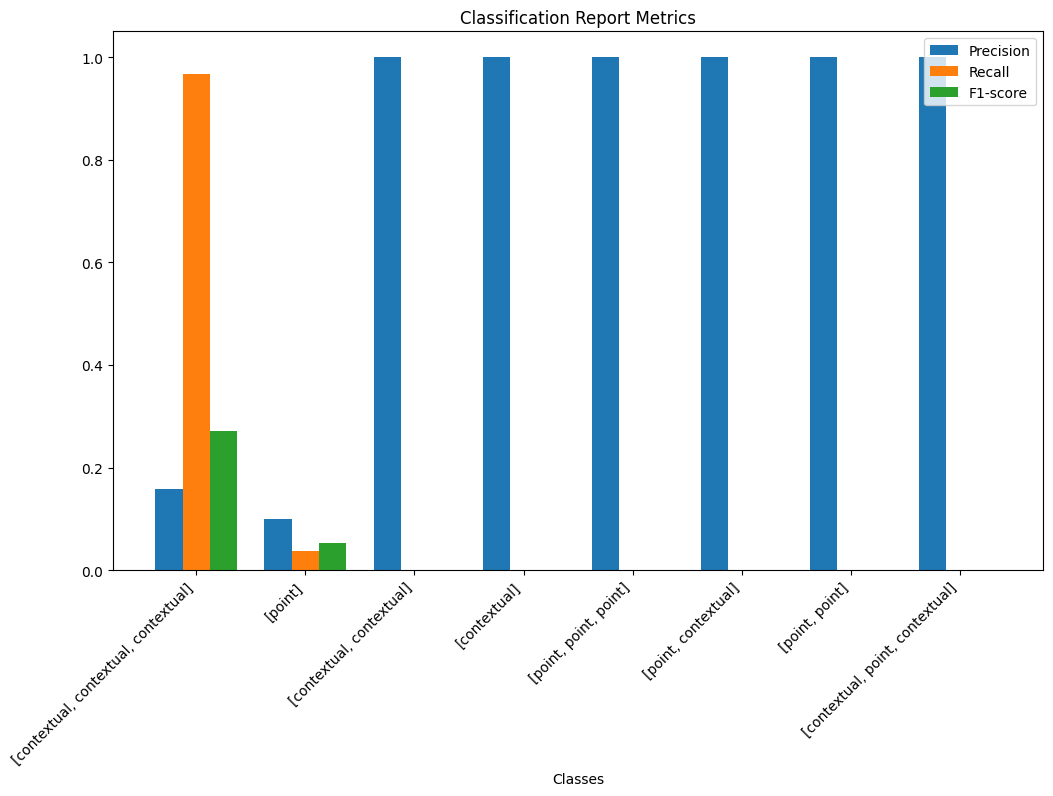

In [8]:
# Classification report for more detailed metrics (Precision, Recall, F1-score)
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=1)

# Extract metrics from the classification report
labels = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', and 'weighted avg'
precision = [report[label]['precision'] for label in labels]
recall = [report[label]['recall'] for label in labels]
f1_score = [report[label]['f1-score'] for label in labels]

# Create a bar chart for Precision, Recall, and F1-score
x = np.arange(len(labels))  # Label locations
width = 0.25  # Bar width

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width, precision, width, label='Precision')
rects2 = ax.bar(x, recall, width, label='Recall')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title, and axes ticks
ax.set_xlabel('Classes')
ax.set_title('Classification Report Metrics')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()

In [9]:
# Attach a label to each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()

plt.show()